In [1]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import (
    TimeSeriesSplit,
)

In [2]:
# XGBoost Model
df = pd.read_parquet('train_dataset_quarterly.parquet')
tscv = TimeSeriesSplit(n_splits=5)

NEW_PRICE_FEATURES = [
    "price_to_sma200", "stddev_252", "max_drawdown_252", "atr_pct",  # Kept from before
    "return_3m", "return_12m", "distance_from_52wk_high"             # New macro momentum
]

NEW_FUND_FEATURES = [
    "roe", "roa", "debt_equity", "current_ratio", "cash_to_assets", "fcf_to_assets", # Static
    "roe_chg_qoq", "roa_chg_qoq", "fcf_to_assets_chg_qoq", "debt_equity_chg_qoq"     # Velocity
]

ALL_FEATURES = NEW_PRICE_FEATURES + NEW_FUND_FEATURES

# Sector is categorical — XGBoost handles it natively via enable_categorical
CATEGORICAL_FEATURES = ["sector"]
FEATURES = ALL_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_TICKERS = {"NBIS", "BRK.B", "AMBP", "CRM", "BE", "FI"}
TICKERS = sorted(set(df["ticker"].unique()) - EXCLUDED_TICKERS)

model_df = df[df["ticker"].isin(TICKERS)].dropna(subset=FEATURES + ["target_return"]).copy()
for c in CATEGORICAL_FEATURES:
    model_df[c] = model_df[c].astype("category")
X = model_df[FEATURES]
y = model_df["target_return"]
dates = model_df["date"]

train_mask = dates < "2023-01-01"
test_mask = dates >= "2023-01-01"

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# --- XGBoost ---

xgb_model = xgb.XGBRegressor(
    objective='reg:pseudohubererror',
    n_estimators=100,        # back to conservative
    max_depth=2,             # back to conservative
    learning_rate=0.05,      # back to conservative
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
)
# --- Winsorize the training target (clip to 1%/99% quantiles) to reduce
# outlier leverage — best-performing XGB variant from the experiment harness ---
lo, hi = y_train.quantile(0.01), y_train.quantile(0.99)
y_train_w = y_train.clip(lo, hi)
n_clipped = int(((y_train < lo) | (y_train > hi)).sum())
print(f"Winsorized target: [{lo:.4f}, {hi:.4f}], clipped {n_clipped}/{len(y_train)} rows")

xgb_model.fit(X_train, y_train_w)
y_pred_xgb = xgb_model.predict(X_test)
ic_xgb = spearmanr(y_test, y_pred_xgb).statistic
test_dates = dates[test_mask].values
per_date = pd.DataFrame({"y": y_test.values, "p": y_pred_xgb, "d": test_dates})
per_date_ic = per_date.groupby("d").apply(lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
print("Winsorized XGB Rank IC (pooled): %.4f" % ic_xgb)
print("Rank IC per-date: mean %.4f  std %.4f  (n_dates=%d)" % (per_date_ic.mean(), per_date_ic.std(), len(per_date_ic)))
print("Directional accuracy: %.2f%%" % (100 * (np.sign(y_test.values) == np.sign(y_pred_xgb)).mean()))

# --- Feature importance (useful diagnostic — which features are actually driving predictions) ---
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)


Winsorized target: [-0.3510, 0.4958], clipped 118/5863 rows
Winsorized XGB Rank IC (pooled): 0.1039
Rank IC per-date: mean 0.0934  std 0.2248  (n_dates=14)
Directional accuracy: 57.14%
atr_pct                    0.139155
max_drawdown_252           0.077671
roa_chg_qoq                0.067135
stddev_252                 0.064864
roe_chg_qoq                0.057889
return_3m                  0.056868
price_to_sma200            0.056703
return_12m                 0.051527
roa                        0.049622
distance_from_52wk_high    0.048901
sector                     0.048055
debt_equity_chg_qoq        0.047862
fcf_to_assets_chg_qoq      0.046584
current_ratio              0.044808
roe                        0.039986
cash_to_assets             0.039115
fcf_to_assets              0.032243
debt_equity                0.031013
dtype: float32


In [3]:
def bucket_returns(returns, edges=(-0.025, 0.0, 0.025, 0.075), 
                    labels=("Strong Sell", "Sell", "Hold", "Buy", "Strong Buy")):
    """
    edges define the boundaries between buckets.
    Example with edges=(-0.05, 0, 0.05, 0.10):
      < -5%        -> Strong Sell
      -5% to 0%    -> Sell
      0% to 5%     -> Hold
      5% to 10%    -> Buy
      >= 10%       -> Strong Buy
    """
    bins = [-np.inf, *edges, np.inf]
    return pd.cut(returns, bins=bins, labels=labels)

# Apply to both actual and predicted returns using the SAME bucket edges
actual_buckets = bucket_returns(pd.Series(y_test).reset_index(drop=True))
pred_buckets   = bucket_returns(pd.Series(y_pred_xgb).reset_index(drop=True))

# Overall accuracy — exact bucket match
acc = accuracy_score(actual_buckets, pred_buckets)
print(f"Bucket classification accuracy: {acc:.2%}")

# Confusion matrix — shows WHERE the model gets it wrong (adjacent bucket vs wildly off)
labels_order = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
cm = confusion_matrix(actual_buckets, pred_buckets, labels=labels_order)
cm_df = pd.DataFrame(cm, index=[f"Actual: {l}" for l in labels_order],
                          columns=[f"Pred: {l}" for l in labels_order])
print(cm_df)

# Per-bucket precision/recall — check if some buckets have almost no predictions (support column)
print(classification_report(actual_buckets, pred_buckets, labels=labels_order, zero_division=0))

# Directional accuracy — a softer, often more meaningful metric: did we get the SIGN right?
directional_acc = (np.sign(y_test) == np.sign(y_pred_xgb)).mean()
print(f"Directional accuracy (up/down only): {directional_acc:.2%}")

Bucket classification accuracy: 15.52%
                     Pred: Strong Sell  Pred: Sell  Pred: Hold  Pred: Buy  \
Actual: Strong Sell                  0           7         223        474   
Actual: Sell                         0           3          57         79   
Actual: Hold                         0           3          57         64   
Actual: Buy                          0           5         103        169   
Actual: Strong Buy                   0          12         201        482   

                     Pred: Strong Buy  
Actual: Strong Sell                43  
Actual: Sell                        7  
Actual: Hold                        4  
Actual: Buy                        16  
Actual: Strong Buy                 98  
              precision    recall  f1-score   support

 Strong Sell       0.00      0.00      0.00       747
        Sell       0.10      0.02      0.03       146
        Hold       0.09      0.45      0.15       128
         Buy       0.13      0.58      0.

In [4]:
# --- 41-feature benchmark: engineered expansion + winsorized XGB (best from harness) ---
def engineer(df):
    d = df.copy().sort_values(["ticker", "date"])
    d["return_6m"] = d.groupby("ticker")["close"].pct_change(2)   # 6m on quarterly grain
    d["return_24m"] = d.groupby("ticker")["close"].pct_change(8)  # 24m on quarterly grain
    vol_mean = d["stddev_252"].mean()
    d["mom6_vol"] = d["return_6m"] / d["stddev_252"].clip(lower=1e-6) * vol_mean
    d["mom12_vol"] = d["return_12m"] / d["stddev_252"].clip(lower=1e-6) * vol_mean
    d["dist_52wk_vol"] = d["distance_from_52wk_high"] / d["stddev_252"].clip(lower=1e-6) * vol_mean
    for c in ["return_3m", "return_6m", "return_12m", "return_24m",
              "roe", "roa", "fcf_to_assets", "price_to_sma200", "distance_from_52wk_high",
              "atr_pct", "debt_equity", "max_drawdown_252"]:
        d[f"rk_{c}"] = d.groupby("date")[c].rank(pct=True)
    for c in ["return_3m", "return_6m", "return_12m", "return_24m"]:
        d[f"rel_{c}"] = d[c] - d.groupby("date")[c].transform("mean")
    return d

FE41 = [
    *NEW_PRICE_FEATURES, *NEW_FUND_FEATURES,            # 17 base
    "sma_200", "max_252",                              # TI/AA cols in parquet but not base list
    "return_6m", "return_24m",
    "mom6_vol", "mom12_vol", "dist_52wk_vol",
    *[f"rk_{c}" for c in ["return_3m", "return_6m", "return_12m", "return_24m",
        "roe", "roa", "fcf_to_assets", "price_to_sma200", "distance_from_52wk_high",
        "atr_pct", "debt_equity", "max_drawdown_252"]],
    *[f"rel_{c}" for c in ["return_3m", "return_6m", "return_12m", "return_24m"]],
]

md41 = engineer(model_df).copy()
md41 = md41.dropna(subset=FE41 + ["sector"]).reset_index(drop=True)
md41["sector"] = md41["sector"].astype("category")
is_test = md41["date"] >= "2023-01-01"
Xtr41, Xte41 = md41.loc[~is_test, FE41], md41.loc[is_test, FE41]
ytr41 = md41.loc[~is_test, "target_return"]
yte41 = md41.loc[is_test, "target_return"]
dte41 = md41.loc[is_test, "date"]
lo41, hi41 = ytr41.quantile([0.01, 0.99])
ytr41w = ytr41.clip(lo41, hi41)
print(f"FE41 len={len(FE41)}  test rows={len(yte41)}  winsor clip {int(((ytr41<lo41)|(ytr41>hi41)).sum())} rows")

xg41 = xgb.XGBRegressor(objective="reg:pseudohubererror", n_estimators=150, max_depth=3,
                        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
                        enable_categorical=True)
xg41.fit(Xtr41, ytr41w)
p41 = xg41.predict(Xte41)

ic41 = spearmanr(yte41, p41).statistic
pc41 = pd.DataFrame({"y": yte41.values, "p": p41, "d": dte41.values})
ic41_date = pc41.groupby("d").apply(lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
dr41 = (np.sign(yte41.values) == np.sign(p41)).mean()
bk41 = accuracy_score(bucket_returns(pd.Series(yte41).reset_index(drop=True)),
                      bucket_returns(pd.Series(p41).reset_index(drop=True)))
print(f"41-feature winsorized XGB: ic_pooled={ic41:.4f}  ic_date={ic41_date.mean():.4f}+/-{ic41_date.std():.3f}  dir={dr41:.2%}  bucket={bk41:.2%}")


FE41 len=40  test rows=2054  winsor clip 90 rows
41-feature winsorized XGB: ic_pooled=0.1231  ic_date=0.0799+/-0.166  dir=56.57%  bucket=16.11%


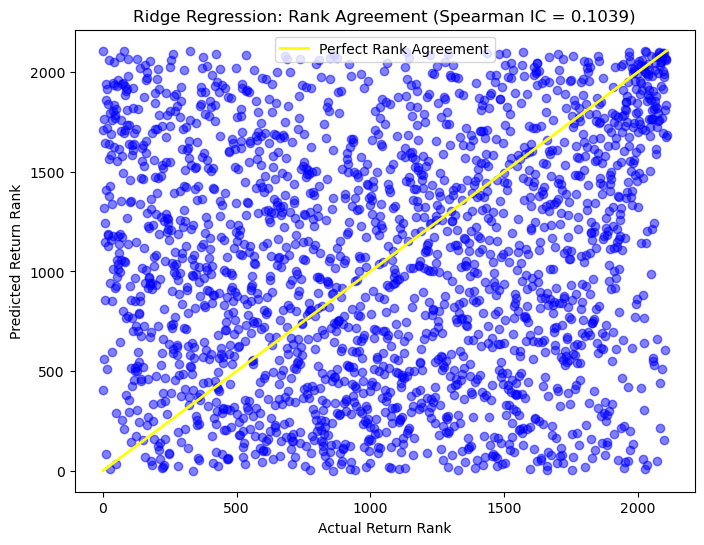

In [5]:
# Plot
# Note: normalize to arrays first — pd.Series(y_test) keeps a non-default index,
# which misaligns against the numpy prediction array (ValueError otherwise).
ic_pooled = spearmanr(y_test, y_pred_xgb).statistic
rank_actual = pd.Series(np.asarray(y_test)).rank().values
rank_pred = pd.Series(np.asarray(y_pred_xgb)).rank().values

plt.figure(figsize=(8, 6))
plt.scatter(rank_actual, rank_pred, color='blue', alpha=0.5)
plt.plot([rank_actual.min(), rank_actual.max()],
         [rank_actual.min(), rank_actual.max()],
         color='yellow', linewidth=2, label='Perfect Rank Agreement')
plt.xlabel("Actual Return Rank")
plt.ylabel("Predicted Return Rank")
plt.title(f"Ridge Regression: Rank Agreement (Spearman IC = {ic_pooled:.4f})")
plt.legend()
plt.show()

## Model zoo — hunt for a better estimator on the same features/target/split

Benchmark to beat (winsorized XGB above): **pooled IC 0.1078, per-date IC 0.1217\u00b10.21, directional 59.51\%**.
All models below train on the winsorized target and share the exact same train/test split.

In [6]:
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import HuberRegressor


def per_date_ic(y_true, y_pred, d):
    pdf = pd.DataFrame({"y": y_true, "p": y_pred, "d": d})
    ic = pdf.groupby("d").apply(lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
    return ic.mean(), ic.std()

zoo = {
    "RidgeCV": RidgeCV(alphas=[1e-2, 1e-1, 1, 1e1]),
    "HuberRegressor": HuberRegressor(max_iter=5000),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=15,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1),
    "HistGBR": HistGradientBoostingRegressor(random_state=42, max_iter=200, learning_rate=0.05),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42, n_jobs=-1),
    "GBR": GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42),
}
X_zoo, d_zoo = model_df.dropna(subset=FEATURES + ["target_return"]), dates
X_zoo_numeric = pd.concat([model_df[ALL_FEATURES], pd.get_dummies(model_df["sector"], prefix="sector")], axis=1)
Xtr_num, Xte_num = X_zoo_numeric[train_mask], X_zoo_numeric[test_mask]

print(f"{'model':16s} {'IC pooled':>10s} {'IC mean':>8s} {'IC std':>7s} {'dir':>7s} {'bucket':>7s}")
for name, m in zoo.items():
    m.fit(Xtr_num, y_train_w)
    p = m.predict(Xte_num)
    icp = spearmanr(y_test, p).statistic
    icm, ics = per_date_ic(y_test.values, p, test_dates)
    dr = (np.sign(y_test.values) == np.sign(p)).mean()
    bk = accuracy_score(bucket_returns(pd.Series(y_test).reset_index(drop=True)),
                        bucket_returns(pd.Series(p).reset_index(drop=True)))
    print(f"{name:16s} {icp:10.4f} {icm:8.4f} {ics:7.4f} {dr:7.2%} {bk:7.2%}")

model             IC pooled  IC mean  IC std     dir  bucket
RidgeCV              0.0977   0.0893  0.1674  56.00%  17.99%
HuberRegressor       0.1005   0.0921  0.1779  56.38%  18.75%
LightGBM             0.0890   0.0764  0.1461  56.86%  16.28%
HistGBR              0.0728   0.0619  0.1336  55.29%  18.75%
RandomForest         0.1004   0.0792  0.2271  57.10%  16.09%
GBR                  0.1158   0.1010  0.1931  57.85%  15.14%


## Cross-grain comparison: does grain change anything?
Same recipe (winsorized XGB + momentum/rank engineering) applied to quarterly, monthly, weekly.
Caveat: target horizons differ (quarterly=3m, monthly=1m, weekly=1w forward), so **Rank IC is the fair comparison**;
directional and bucketing have grain-specific always-up baselines and bucket scaling.

In [7]:
# Same engineering recipe, scaled to each grain's bars-per-horizon, then winsorized XGB.
GRAINS = {
    "quarterly": "train_dataset_quarterly.parquet",
    "monthly":   "train_dataset.parquet",
    "weekly":    "train_dataset_weekly.parquet",
}
# quarter-months per bar: quarterly=3, monthly=1, weekly=0.25
BARS_PER_3M = {"quarterly": 1, "monthly": 3, "weekly": 13}
# baseline column sets already in each parquet (legacy TI for monthly/weekly)
BASE_BY_GRAIN = {
"quarterly": NEW_PRICE_FEATURES + NEW_FUND_FEATURES,
    "monthly":   ["sma_20","sma_50","sma_200","ema_12","ema_26","rsi_14","adx_14","atr_14",
                   "macd_hist","stoch_k_14","stoch_d_14","cci_20","price_to_sma20","price_to_sma50",
                   "price_to_sma200","stddev_252","max_drawdown_252","atr_pct",
                   "roe","roa","debt_equity","current_ratio","cash_to_assets","fcf_to_assets"],
    "weekly":    ["sma_20","sma_50","sma_200","ema_12","ema_26","rsi_14","adx_14","atr_14",
                   "macd_hist","stoch_k_14","stoch_d_14","cci_20","price_to_sma20","price_to_sma50",
                   "price_to_sma200","stddev_252","max_drawdown_252","atr_pct",
                   "roe","roa","debt_equity","current_ratio","cash_to_assets","fcf_to_assets"],
}

def engineer_grain(df, p3):
    d = df.copy().sort_values(["ticker", "date"])
    for lbl, bp in [("3m", p3), ("6m", 2*p3), ("12m", 4*p3), ("24m", 8*p3)]:
        d[f"ret_{lbl}"] = d.groupby("ticker")["close"].pct_change(bp)
    for lbl in ["3m", "6m", "12m", "24m"]:
        d[f"rk_ret_{lbl}"] = d.groupby("date")[f"ret_{lbl}"].rank(pct=True)
        d[f"rel_ret_{lbl}"] = d[f"ret_{lbl}"] - d.groupby("date")[f"ret_{lbl}"].transform("mean")
    return d

# sector is current/static -> reuse quarterly's ticker->sector map for the other grains
sect_map = pd.read_parquet("train_dataset_quarterly.parquet")[["ticker", "sector"]].drop_duplicates("ticker")

print(f"{'grain':10s} {'feats':>5s} {'ic_pooled':>10s} {'ic_date':>9s} {'dir':>7s} {'always-up':>9s}")
for grain, f in GRAINS.items():
    gdf = pd.read_parquet(f)
    gdf = gdf.drop(columns=["sector"], errors="ignore").merge(sect_map, on="ticker", how="left")
    gdf = gdf[gdf.ticker.isin(TICKERS)].copy()
    gdf = engineer_grain(gdf, BARS_PER_3M[grain])
    feats = BASE_BY_GRAIN[grain] + [c for c in gdf.columns if c.startswith(("ret_", "rk_ret_", "rel_ret_"))]
    gdf = gdf.dropna(subset=feats + ["target_return", "sector"]).reset_index(drop=True)
    gdf["sector"] = gdf["sector"].astype("category")
    is_test = gdf["date"] >= "2023-01-01"
    Xtr, Xte = gdf.loc[~is_test, feats], gdf.loc[is_test, feats]
    ytr = gdf.loc[~is_test, "target_return"]
    yte, dte = gdf.loc[is_test, "target_return"], gdf.loc[is_test, "date"]
    lo, hi = ytr.quantile([0.01, 0.99]); ytrw = ytr.clip(lo, hi)
    m = xgb.XGBRegressor(objective="reg:pseudohubererror", n_estimators=150, max_depth=3,
                         learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                         reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
                         enable_categorical=True)
    m.fit(Xtr, ytrw)
    p = m.predict(Xte)
    icp = spearmanr(yte, p).statistic
    pdl = pd.DataFrame({"y": yte.values, "p": p, "d": dte.values})
    icd = pdl.groupby("d").apply(lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
    dr = (np.sign(yte.values) == np.sign(p)).mean()
    au = (yte > 0).mean()
    print(f"{grain:10s} {len(feats):5d} {icp:10.4f} {icd.mean():9.4f} {dr:7.2%} {au:9.2%}")


grain      feats  ic_pooled   ic_date     dir always-up
quarterly     29     0.1366    0.1080  57.60%    57.60%
monthly       36     0.0527    0.0180  53.54%    54.55%
weekly        36     0.0412    0.0279  52.63%    53.23%


## Fix #1 : train direction directly (threshold-tuned classifier) + PIT market regime + multiclass buckets
Three changes vs the regressor-cut approach:
1. **Direction as classification** (`binary:logistic`) with the decision threshold tuned on **time-series validation folds**, not hardcoded at 0.50. Predicting \"up\" when P>0.50 collapses to the always-up baseline whenever base rate u>0.5.
2. **PIT market regime feature**: cross-sectional mean of trailing-3m returns as-of the row (verified `target_return[t]==return_3m[t+1]`, so no leakage) — direction of individual names is dominated by the market move.
3. **Multiclass on equal-frequency (quantile) buckets** instead of cutting a regression output — learns the dispersion, not just the conditional mean.

In [8]:
# --- Rebuild engineered frame + PIT market factor (self-contained) ---
md_c = engineer(model_df).copy()
md_c["market_ret"] = md_c.groupby("date")["return_3m"].transform("mean")
FE_C = FE41 + ["market_ret"]
md_c = md_c.dropna(subset=FE_C + ["sector"]).reset_index(drop=True)
md_c["sector"] = md_c["sector"].astype("category")
tst = md_c["date"] >= "2023-01-01"
Xc_tr, Xc_te = md_c.loc[~tst, FE_C], md_c.loc[tst, FE_C]
yc_tr = md_c.loc[~tst, "target_return"]
yte_c, dte_c = md_c.loc[tst, "target_return"], md_c.loc[tst, "date"]

CLF = dict(objective="binary:logistic", n_estimators=200, max_depth=3, learning_rate=0.05,
           subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
           random_state=42, n_jobs=-1, enable_categorical=True)

# --- 1) Direction classifier, threshold tuned on time-series validation (train window only) ---
clf = xgb.XGBClassifier(**CLF)
clf.fit(Xc_tr, (yc_tr > 0).astype(int))
p_clf = clf.predict_proba(Xc_te)[:, 1]

# tune threshold on TimeSeriesSplit folds of the TRAIN window (no test leakage)
from sklearn.model_selection import TimeSeriesSplit as TSS

tss = TSS(n_splits=5)
grid = np.arange(0.30, 0.71, 0.01)
fold_acc = {t: [] for t in grid}
for tri, vai in tss.split(Xc_tr):
    m = xgb.XGBClassifier(**CLF)
    m.fit(Xc_tr.iloc[tri], (yc_tr.iloc[tri] > 0).astype(int))
    pv = m.predict_proba(Xc_tr.iloc[vai])[:, 1]
    yv = (yc_tr.iloc[vai] > 0).astype(int).values
    for t in grid:
        fold_acc[t].append((pv > t).astype(int) == yv)
cv_dir = {t: np.mean(np.concatenate(v)) for t, v in fold_acc.items()}
best_t = max(cv_dir, key=cv_dir.get)

dir_05  = (p_clf > 0.50).astype(int)
dir_bt  = (p_clf > best_t).astype(int)
print(f"classifier P(up): best threshold t={best_t:.2f} (train-CV dir={cv_dir[best_t]:.2%})")
print(f"  test dir @0.50        : {(dir_05 == (yte_c>0).values).mean():.2%}   always-up={ (yte_c>0).mean():.2%}")
print(f"  test dir @best t={best_t:.2f}: {(dir_bt == (yte_c>0).values).mean():.2%}")
print(f"  rank IC of classifier scores: {spearmanr(yte_c, p_clf).statistic:.4f}")

# --- 3) Multiclass on equal-frequency (quantile) buckets, fit on train only ---
qts = np.quantile(yc_tr, [0.2, 0.4, 0.6, 0.8])
edges = np.concatenate([[-np.inf], qts, [np.inf]])
labels = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
yb_tr = pd.cut(yc_tr, bins=edges, labels=range(5)).astype(int)
yb_te = pd.cut(yte_c, bins=edges, labels=range(5)).astype(int)
mc = xgb.XGBClassifier(objective="multi:softprob", num_class=5, n_estimators=200, max_depth=3,
                       learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                       reg_lambda=1.0, random_state=42, n_jobs=-1, enable_categorical=True)
mc.fit(Xc_tr, yb_tr)
pb = mc.predict(Xc_te)
acc_b = accuracy_score(yb_te, pb)
adj = accuracy_score(yb_te, (abs(pb - yb_te) <= 1).astype(int))  # adjacent-bucket (1-off) accuracy
print(f"\nmc buckets (quantile edges {qts.round(3)}): exact={acc_b:.2%}  adjacent(1-off)={adj:.2%}")
print(f"  baseline exact: {max((yb_te==k).mean() for k in range(5)):.2%} (always-most-common bucket)")


classifier P(up): best threshold t=0.46 (train-CV dir=69.11%)
  test dir @0.50        : 52.29%   always-up=57.59%
  test dir @best t=0.46: 52.53%
  rank IC of classifier scores: 0.0452

mc buckets (quantile edges [-0.071  0.005  0.069  0.146]): exact=26.53%  adjacent(1-off)=26.58%
  baseline exact: 24.05% (always-most-common bucket)


## Fix #2 : market-neutral decomposition
Direction is dominated by the market move, and the previous cell showed a raw `market_ret` feature makes the classifier collapse to tagging everyone with the market (rank IC \u2248 0).
Decompose instead: `return = market + idiosyncratic`.
- Train the regressor on **per-date demeaned target** (`idios = target - market_forward`). This is exactly what per-date rank IC measures \u2014 aligning the loss with the evaluation metric. Note the demeaned target needs no future info: market_forward[t] is the same-date cross-sectional mean.
- Fit an **AR(1) PIT market forecast** on the trailing market factor from the train window only, apply it to test dates, then add it back: `pred_total = pred_idios + market_forecast`.
- Control: re-run the direction classifier **without** `market_ret` to isolate feature vs binary-loss.


In [9]:
# --- Demeaned (idiosyncratic) target: no leakage, target_return[t]==return_3m[t+1] verified ---
md_m = engineer(model_df).copy()
mkt_tr = md_m.groupby("date")["return_3m"].transform("mean")          # trailing 3m market factor (PIT)
md_m["market_ret"] = mkt_tr
md_m["idios"] = md_m["target_return"] - md_m.groupby("date")["target_return"].transform("mean")
FE_M = FE41 + ["market_ret"]
md_m = md_m.dropna(subset=FE_M + ["sector"]).reset_index(drop=True)
md_m["sector"] = md_m["sector"].astype("category")
tst = md_m["date"] >= "2023-01-01"
Xm_tr, Xm_te = md_m.loc[~tst, FE_M], md_m.loc[tst, FE_M]
im_tr, im_te = md_m.loc[~tst, "idios"], md_m.loc[tst, "idios"]
tr_mkt, te_mkt = md_m.loc[~tst, "market_ret"], md_m.loc[tst, "market_ret"]
yte_m = md_m.loc[tst, "target_return"]

# winsorize train idiosyncratic labels
lo, hi = im_tr.quantile([0.01, 0.99]); im_tr_w = im_tr.clip(lo, hi)

def xgb_reg(**kw):
    return xgb.XGBRegressor(objective="reg:pseudohubererror", n_estimators=200, max_depth=3,
                            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, n_jobs=-1, enable_categorical=True, **kw)

reg = xgb_reg(); reg.fit(Xm_tr, im_tr_w)
p_idios = reg.predict(Xm_te)

# --- AR(1) PIT market forecast from train window only ---
s_m = tr_mkt.groupby(md_m.loc[~tst, "date"]).first().sort_index()
x_ar, y_ar = s_m.values[:-1], s_m.values[1:]
a, b = np.polyfit(x_ar, y_ar, 1)
te_mkt_d = te_mkt.groupby(md_m.loc[tst, "date"]).first().sort_index()
forecast_d = a * te_mkt_d.values + b
print(f"AR(1) market forecast: y = {a:.4f}*x + {b:.4f}   (train n={len(s_m)-1}, r2={1 - np.var(np.subtract(y_ar, a*x_ar+b))/np.var(y_ar):+.3f})")
print(f"  market fwd per test date: forecast {forecast_d.round(3)[:5]}... actual (cross-sec mean) {te_mkt_d.round(3).values[:5]}...")

# add back per-date forecast to per-row idios prediction
fore_row = te_mkt.groupby(md_m.loc[tst, "date"]).transform("first")
fcast_row = (a * fore_row.values + b)
p_total = p_idios + fcast_row

def report(tag, p):
    icp = spearmanr(yte_m, p).statistic
    icd = pd.DataFrame({"y": yte_m.values, "p": p, "d": md_m.loc[tst, "date"].values})
    icdm = icd.groupby("d").apply(lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
    dr = (np.sign(yte_m.values) == np.sign(p)).mean()
    au = (yte_m > 0).mean()
    print(f"{tag:34s} ic_pooled={icp:+.4f} ic_date={icdm.mean():+.4f} dir={dr:.2%}  (always-up {au:.2%})")

report("idios-only (reg on demeaned)", p_idios)
report("idios + AR(1) market fwd",      p_total)
report("idios + perfect market fwd",    p_idios + te_mkt.values)   # ceiling: know future market move

# --- Buy decision as top-quintile vs bottom-quintile (the meaningful signal) ---
qid = np.argsort(p_total)
n = len(qid); top = qid[-n//5:]; bot = qid[:n//5]
print(f"\nbuy=top20%: P(up)={ (yte_m.values[top]>0).mean():.2%}   sell=bottom20%: P(up)={ (yte_m.values[bot]>0).mean():.2%}   (lift {(yte_m.values[top]>0).mean()/(yte_m.values[bot]>0).mean():.2f}x)")

# --- Control: direction classifier WITHOUT market_ret (isolate feature vs binary loss) ---
FE_NM = [f for f in FE_C if f != "market_ret"]
md_nm = engineer(model_df).copy().dropna(subset=FE_NM + ["sector"]).reset_index(drop=True)
md_nm["sector"] = md_nm["sector"].astype("category")
ts2 = md_nm["date"] >= "2023-01-01"
clf2 = xgb.XGBClassifier(objective="binary:logistic", n_estimators=200, max_depth=3, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                        random_state=42, n_jobs=-1, enable_categorical=True)
clf2.fit(md_nm.loc[~ts2, FE_NM], (md_nm.loc[~ts2, "target_return"] > 0).astype(int))
pc2 = clf2.predict_proba(md_nm.loc[ts2, FE_NM])[:, 1]
icp2 = spearmanr(md_nm.loc[ts2, "target_return"], pc2).statistic
dr2 = (np.sign(pc2 - 0.5) == np.sign(md_nm.loc[ts2, "target_return"].values)).mean()
print(f"\nclassifier no-market_ret: rank IC={icp2:+.4f}  dir@0.5={dr2:.2%}  (always-up {(md_nm.loc[ts2,'target_return']>0).mean():.2%})")


AR(1) market forecast: y = -0.2525*x + 0.0485   (train n=33, r2=+0.063)
  market fwd per test date: forecast [0.028 0.03  0.054 0.017 0.024]... actual (cross-sec mean) [ 0.082  0.072 -0.023  0.125  0.097]...
idios-only (reg on demeaned)       ic_pooled=+0.0401 ic_date=+0.0556 dir=48.20%  (always-up 57.59%)
idios + AR(1) market fwd           ic_pooled=+0.0459 ic_date=+0.0556 dir=56.04%  (always-up 57.59%)
idios + perfect market fwd         ic_pooled=-0.0216 ic_date=+0.0556 dir=50.29%  (always-up 57.59%)

buy=top20%: P(up)=64.23%   sell=bottom20%: P(up)=57.07%   (lift 1.13x)

classifier no-market_ret: rank IC=+0.0871  dir@0.5=57.55%  (always-up 57.59%)


## Fair apples-to-apples across grains
Earlier cross-grain test used the legacy TI feature set for monthly/weekly with only momentum-style engineering \u2014 unfair. Here every grain gets the **full toolkit**:
- fundamental velocity `*_chg_qoq` = roe/roa/fcf/debt minus value `bars_per_quarter` ago (PIT; bars = 1/3/13 for quarterly/monthly/weekly)
- momentum lookbacks `ret_3m/6m/12m/24m` scaled to grain, plus vol-scaled versions
- per-date cross-sectional ranks `rk_*` and market-relative `rel_*` over momentum + fundamentals + key price/tech features
- sector joined (static), same winsorized-XGB recipe
Then compare rank lift (top vs bottom quintile P(up)) and directional gap to always-up.

In [10]:
GROUPS = {
    "quarterly": {"file": "train_dataset_quarterly.parquet", "bq": 1,   # bars per quarter
                   "base": NEW_PRICE_FEATURES + NEW_FUND_FEATURES},
    "monthly":   {"file": "train_dataset.parquet",          "bq": 3,
                   "base": ["sma_20","sma_50","sma_200","ema_12","ema_26","rsi_14","adx_14","atr_14",
                             "macd_hist","stoch_k_14","stoch_d_14","cci_20","price_to_sma20","price_to_sma50",
                             "price_to_sma200","stddev_252","max_drawdown_252","atr_pct",
                             "roe","roa","debt_equity","current_ratio","cash_to_assets","fcf_to_assets"]},
    "weekly":     {"file": "train_dataset_weekly.parquet",   "bq": 13,
                   "base": ["sma_20","sma_50","sma_200","ema_12","ema_26","rsi_14","adx_14","atr_14",
                             "macd_hist","stoch_k_14","stoch_d_14","cci_20","price_to_sma20","price_to_sma50",
                             "price_to_sma200","stddev_252","max_drawdown_252","atr_pct",
                             "roe","roa","debt_equity","current_ratio","cash_to_assets","fcf_to_assets"]},
}

def engineer_zoo(df, bq):
    d = df.copy().sort_values(["ticker","date"])
    g = d.groupby("ticker")
    # fundamental velocity: value now minus value bars_per_quarter ago (one fiscal quarter)
    for c in ["roe","roa","fcf_to_assets","debt_equity"]:
        if c in d: d[f"{c}_chg_qoq"] = d[c] - g[c].shift(bq)
    # momentum lookbacks scaled to grain, plus vol-scaled versions
    vm = d["stddev_252"].clip(lower=1e-6).mean()
    for lbl,bp in [("3m",bq),("6m",2*bq),("12m",4*bq),("24m",8*bq)]:
        d[f"ret_{lbl}"] = g["close"].pct_change(bp)
        d[f"mom{lbl}_vol"] = d[f"ret_{lbl}"] / d["stddev_252"].clip(lower=1e-6) * vm
    # cross-sectional ranks + market-relative over momentum + fundamentals + price/tech
    rank_cols = [f"ret_{l}" for l in ["3m","6m","12m","24m"]] + \
                [c for c in ["roe","roa","fcf_to_assets","debt_equity","price_to_sma200","price_to_sma20",
                             "atr_pct","rsi_14","macd_hist","adx_14","stoch_k_14","cci_20","max_drawdown_252"] if c in d]
    for c in rank_cols:
        d[f"rk_{c}"] = d.groupby("date")[c].rank(pct=True)
        d[f"rel_{c}"] = d[c] - d.groupby("date")[c].transform("mean")
    return d

sect_map2 = pd.read_parquet("train_dataset_quarterly.parquet")[["ticker","sector"]].drop_duplicates("ticker")

def run_fair(grain):
    cfg = GROUPS[grain]
    d = pd.read_parquet(cfg["file"]).drop(columns=["sector"], errors="ignore").merge(sect_map2, on="ticker", how="left")
    d = d[d.ticker.isin(TICKERS)].copy()
    d = engineer_zoo(d, cfg["bq"])
    feats = cfg["base"] + [c for c in d.columns if c not in cfg["base"]+["ticker","date","sector","target_return","asof_date"]
                           and not c.startswith(("open","high","low","close","volume"))]
    d = d.dropna(subset=feats + ["sector"]).reset_index(drop=True)
    d["sector"] = d["sector"].astype("category")
    tst = d["date"] >= "2023-01-01"
    Xtr, Xte = d.loc[~tst, feats], d.loc[tst, feats]
    ytr = d.loc[~tst, "target_return"]
    yte, dte = d.loc[tst, "target_return"], d.loc[tst, "date"]
    lo, hi = ytr.quantile([0.01,0.99]); ytrw = ytr.clip(lo,hi)
    m = xgb.XGBRegressor(objective="reg:pseudohubererror", n_estimators=200, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                         n_jobs=-1, enable_categorical=True)
    m.fit(Xtr, ytrw)
    p = m.predict(Xte)
    icp = spearmanr(yte, p).statistic
    icd = pd.DataFrame({"y": yte.values, "p": p, "d": dte.values}).groupby("d").apply(
        lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
    dr = (np.sign(yte.values)==np.sign(p)).mean(); au = (yte>0).mean()
    qq = np.argsort(p); n=len(qq); top, bot = qq[-n//5:], qq[:n//5]
    lift = (yte.values[top]>0).mean() / (yte.values[bot]>0).mean()
    qts = np.quantile(ytr,[0.2,0.4,0.6,0.8]); edges=np.concatenate([[-np.inf],qts,[np.inf]])
    bk = accuracy_score(pd.cut(yte,bins=edges,labels=range(5)).astype(int),
                        pd.cut(pd.Series(p),bins=edges,labels=range(5)).astype(int))
    print(f"{grain:10s} feats={len(feats):3d} n_test={len(yte):5d} ic_pooled={icp:+.4f} ic_date={icd.mean():+.4f}"
          f" dir={dr:.2%}(au {au:.2%}) top20P={ (yte.values[top]>0).mean():.2%} bot20P={ (yte.values[bot]>0).mean():.2%}"
          f" lift={lift:.2f}x bucket={bk:.2%}")

print(f"{'grain':10s} {'feats':>5s} {'n_test':>6s} {'ic_pooled':>10s} {'ic_date':>8s} {'dir':>8s} {'top20':>6s} {'bot20':>6s} {'lift':>6s} {'bucket':>7s}")
for g in GROUPS: run_fair(g)


grain      feats n_test  ic_pooled  ic_date      dir  top20  bot20   lift  bucket
quarterly  feats= 56 n_test= 1661 ic_pooled=-0.0014 ic_date=+0.0523 dir=47.26%(au 57.13%) top20P=57.66% bot20P=60.54% lift=0.95x bucket=19.81%
monthly    feats= 76 n_test= 5882 ic_pooled=+0.0953 ic_date=+0.0073 dir=53.33%(au 54.20%) top20P=58.03% bot20P=49.32% lift=1.18x bucket=20.64%
weekly     feats= 76 n_test=26535 ic_pooled=-0.0042 ic_date=+0.0008 dir=51.48%(au 53.51%) top20P=52.25% bot20P=52.52% lift=0.99x bucket=20.61%


In [11]:
# --- FRED market-regime features: does VIX / S&P500 regime add signal on top of FE41? ---
MKT      = ["vix","vix_pctile_252","vix_chg_21d"]
MKT_SPX  = ["spx_ret_21d","spx_ret_63d","spx_ret_252d"]

def run_mkt(grain, base, extra, drop_cols, label):
    cfg = GROUPS[grain]
    d = pd.read_parquet(cfg["file"]).drop(columns=["sector"], errors="ignore").merge(sect_map2, on="ticker", how="left")
    d = d[d.ticker.isin(TICKERS)].copy()
    d = engineer_zoo(d, cfg["bq"])
    drop = ["ticker","date","sector","target_return","asof_date"] + list(drop_cols) + list(extra)
    z = [c for c in d.columns if c not in base + drop and not c.startswith(("open","high","low","close","volume"))]
    feats = base + list(extra) + z
    # dropna on the BASE subset only: pre-2016 market NaNs are KEPT for XGBoost
    d = d.dropna(subset=base + ["sector"]).reset_index(drop=True)
    d["sector"] = d["sector"].astype("category")
    tst = d["date"] >= "2023-01-01"
    Xtr, Xte = d.loc[~tst, feats], d.loc[tst, feats]
    ytr = d.loc[~tst, "target_return"]
    yte, dte = d.loc[tst, "target_return"], d.loc[tst, "date"]
    lo, hi = ytr.quantile([0.01,0.99]); ytrw = ytr.clip(lo,hi)
    m = xgb.XGBRegressor(objective="reg:pseudohubererror", n_estimators=200, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                         n_jobs=-1, enable_categorical=True)
    m.fit(Xtr, ytrw)
    p = m.predict(Xte)
    icp = spearmanr(yte, p).statistic
    icd = pd.DataFrame({"y": yte.values, "p": p, "d": dte.values}).groupby("d").apply(
        lambda g: spearmanr(g["y"], g["p"]).statistic, include_groups=False)
    dr = (np.sign(yte.values)==np.sign(p)).mean(); au = (yte>0).mean()
    qq = np.argsort(p); n=len(qq); top, bot = qq[-n//5:], qq[:n//5]
    lift = (yte.values[top]>0).mean() / (yte.values[bot]>0).mean()
    qts = np.quantile(ytr,[0.2,0.4,0.6,0.8]); edges=np.concatenate([[-np.inf],qts,[np.inf]])
    bk = accuracy_score(pd.cut(yte,bins=edges,labels=range(5)).astype(int),
                        pd.cut(pd.Series(p),bins=edges,labels=range(5)).astype(int))
    print(f"{label:14s} feats={len(feats):3d} n_test={len(yte):5d} ic_pooled={icp:+.4f} ic_date={icd.mean():+.4f}"
          f" dir={dr:.2%}(au {au:.2%}) top20P={ (yte.values[top]>0).mean():.2%} bot20P={ (yte.values[bot]>0).mean():.2%}"
          f" lift={lift:.2f}x bucket={bk:.2%}")

BASE_Q = GROUPS["quarterly"]["base"]
print(f"{'variant':14s} {'feats':>4s} {'n_test':>6s} {'ic_pooled':>9s} {'ic_date':>8s} {'dir':>13s} {'top20':>6s} {'bot20':>6s} {'lift':>6s} {'bucket':>7s}")
run_mkt("quarterly", BASE_Q, [],       MKT+MKT_SPX, "FE41 no-mkt")
run_mkt("quarterly", BASE_Q, MKT+MKT_SPX, [],        "FE41 + mkt")
run_mkt("quarterly", BASE_Q, MKT,      MKT_SPX,     "FE41 + vix")
run_mkt("quarterly", BASE_Q, MKT_SPX,  MKT,         "FE41 + spx")


variant        feats n_test ic_pooled  ic_date           dir  top20  bot20   lift  bucket
FE41 no-mkt    feats= 50 n_test= 2111 ic_pooled=+0.0956 ic_date=+0.0724 dir=56.47%(au 57.60%) top20P=62.41% bot20P=54.03% lift=1.16x bucket=16.58%
FE41 + mkt     feats= 56 n_test= 2111 ic_pooled=+0.0283 ic_date=+0.0534 dir=49.41%(au 57.60%) top20P=57.45% bot20P=54.74% lift=1.05x bucket=19.52%
FE41 + vix     feats= 53 n_test= 2111 ic_pooled=+0.1120 ic_date=+0.0983 dir=57.93%(au 57.60%) top20P=62.41% bot20P=54.27% lift=1.15x bucket=16.72%
FE41 + spx     feats= 53 n_test= 2111 ic_pooled=+0.0210 ic_date=+0.0815 dir=48.22%(au 57.60%) top20P=57.21% bot20P=57.35% lift=1.00x bucket=19.94%


## Basic LSTM: can a sequential model beat point-in-time XGBoost?

Same engineered monthly features and identical rows, two models:
1. **LSTM** — 12-month lookback sequence per ticker (strict calendar, NaN rows dropped per ticker), 2-layer LSTM (hidden 32), regresses the winsorized 3-month-forward return.
2. **XGBoost control** — the same features taken only at period `t` (the window end), same rows and split.

Split on sequence-end date: train `date < 2023-01-01`, test `>= 2023-01-01`. Window features are strictly in the past of the labelled period, so no PIT leakage (features as-of `t`, label `target_return[t]` realizes forward). Metrics mirror the FRED ablation cell for a direct comparison.

In [ ]:
# --- Basic LSTM vs same-feature XGBoost (monthly grain, identical rows) ---
import torch
from torch import nn

LSTM_FEATS = ["ret_3m","ret_12m","ret_24m","price_to_sma200","sma_20","rsi_14","cci_20",
              "stddev_252","atr_pct","max_drawdown_252","roe","debt_equity","fcf_to_assets","rel_ret_12m"]

md_l = pd.read_parquet(GROUPS["monthly"]["file"]).drop(columns=["sector"], errors="ignore") \
    .merge(sect_map2, on="ticker", how="left")
md_l = md_l[md_l.ticker.isin(TICKERS)].pipe(lambda d: engineer_zoo(d, GROUPS["monthly"]["bq"]))

def lstm_windows(df, feats, lb=12):
    Xw, yw, dw = [], [], []
    for _, g in df.groupby("ticker"):
        g = g.sort_values("date").dropna(subset=feats + ["target_return"])
        a = g[feats].values
        for i in range(lb, len(a)):
            Xw.append(a[i-lb:i]);  yw.append(g["target_return"].iloc[i]);  dw.append(g["date"].iloc[i])
    return np.stack(Xw), np.array(yw), np.array(dw, dtype="datetime64[ns]")

Xw, yw, dw = lstm_windows(md_l, LSTM_FEATS)
tr = dw < np.datetime64("2023-01-01")
Xtr3, Xte3 = Xw[tr], Xw[~tr];  ytr3, yte3, dte3 = yw[tr], yw[~tr], dw[~tr]
print(f"sequences: train {len(ytr3)}  test {len(yte3)}  (window={Xw.shape[1]}, feats={Xw.shape[2]})")
mu, sd = Xtr3.reshape(-1, Xtr3.shape[-1]).mean(0), Xtr3.reshape(-1, Xtr3.shape[-1]).std(0)+1e-9
Xtr3=(Xtr3-mu)/sd; Xte3=(Xte3-mu)/sd
lo,hi = np.quantile(ytr3,[0.01,0.99]); yw_=np.clip(ytr3,lo,hi); ym,ys=yw_.mean(),yw_.std()+1e-9

class LSTM(nn.Module):
    def __init__(s, nin, h=32, L=2, dp=0.2):
        super().__init__(); s.lstm=nn.LSTM(nin,h,L,batch_first=True,dropout=dp); s.hd=nn.Linear(h,1)
    def forward(s,x):
        o,_=s.lstm(x); return s.hd(o[:,-1,:]).squeeze(-1)

torch.manual_seed(42)
m_=LSTM(len(LSTM_FEATS)); opt=torch.optim.Adam(m_.parameters(),lr=1e-3); lossf=nn.MSELoss()
Xa=torch.from_numpy(Xtr3).float(); ya=torch.from_numpy((yw_-ym)/ys).float(); Xea=torch.from_numpy(Xte3).float()
for ep in range(20):
    m_.train(); perm=torch.randperm(len(Xa)); tot=0.0
    for i in range(0,len(Xa),64):
        idx=perm[i:i+64]; opt.zero_grad(); l=lossf(m_(Xa[idx]),ya[idx]); l.backward(); opt.step(); tot+=l.item()*len(idx)
    if (ep+1)%5==0: print(f"  epoch {ep+1:2d}/20 train_mse={tot/len(Xa):.4f}")
m_.eval()
with torch.no_grad(): p_lstm=m_(Xea).numpy()*ys+ym

def mreport(tag, p, y=None, d=None):
    y = np.asarray(ytr3 if y is None else y); d = np.asarray(dte3 if d is None else d)
    icp=spearmanr(y,p).statistic
    icd=pd.DataFrame({"y":y,"p":p,"d":d}).groupby("d").apply(lambda g:spearmanr(g["y"],g["p"]).statistic,include_groups=False)
    dr=(np.sign(y)==np.sign(p)).mean(); au=(y>0).mean()
    qq=np.argsort(p); n=len(qq); top,bot=qq[-n//5:],qq[:n//5]
    lift=(y[top]>0).mean()/(y[bot]>0).mean()
    qts=np.quantile(ytr3,[0.2,0.4,0.6,0.8]); edges=np.concatenate([[-np.inf],qts,[np.inf]])
    bk=accuracy_score(pd.cut(pd.Series(y),bins=edges,labels=range(5)).astype(int),
                      pd.cut(pd.Series(p),bins=edges,labels=range(5)).astype(int))
    print(f"{tag:26s} n={len(y):5d} ic_pooled={icp:+.4f} ic_date={icd.mean():+.4f} dir={dr:.2%}(au {au:.2%}) "
          f"top20P={(y[top]>0).mean():.2%} bot20P={(y[bot]>0).mean():.2%} lift={lift:.2f}x bucket={bk:.2%}")

mreport("LSTM (12m seq, monthly)", p_lstm)

# same-feature, same-rows point-in-time XGB control (uses only period-end feature row)
import xgboost as xgb

Xr_tr, Xr_te = Xtr3[:,-1,:], Xte3[:,-1,:]
xg=xgb.XGBRegressor(objective="reg:pseudohubererror",n_estimators=200,max_depth=3,learning_rate=0.05,
                    subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,random_state=42,n_jobs=-1)
xg.fit(Xr_tr,yw_); p_xg=xg.predict(Xr_te)
mreport("XGB same feats+rows (PIT)", p_xg)

sequences: train 18103  test 8519  (window=12, feats=14)
